In [1]:
# === Cell 1: Import libraries and load data ===
# Rationale: Self-contained notebook — reload everything from scratch
# so anyone can run this independently.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display

# Load and clean data
metadata = pd.read_csv('../data/metadata.csv', sep=';')
asv_table = pd.read_excel('../data/seqtab_nochim_export.xlsx')
asv_table = asv_table.rename(columns={'Unnamed: 0': 'SampleID'}).set_index('SampleID')

print(f"ASV table: {asv_table.shape[0]} samples x {asv_table.shape[1]} ASVs")
print(f"Disease groups: {dict(metadata['DiseaseStatus'].value_counts())}")

ASV table: 59 samples x 6693 ASVs
Disease groups: {'Colorectal cancer': np.int64(21), 'Healthy': np.int64(19), 'Adenomatous Polyps': np.int64(19)}


In [2]:
# === Cell 2: Compute Bray-Curtis distance matrix ===
# Rationale: Bray-Curtis is the standard distance metric in microbiome studies.
# It measures how different two samples are based on their species abundances.
# Values range from 0 (identical composition) to 1 (completely different).
# We first convert counts to relative abundance to account for differences
# in sequencing depth, then compute pairwise distances between all 59 samples.

from skbio import DistanceMatrix
from skbio.diversity import beta_diversity

# Convert to relative abundance (proportions)
relative = asv_table.div(asv_table.sum(axis=1), axis=0)

# Compute Bray-Curtis distance matrix
bc_dm = beta_diversity('braycurtis', relative.values, ids=relative.index)

print(f"Distance matrix shape: {bc_dm.shape}")
print(f"\nExample: distance between first two samples")
print(f"  {relative.index[0]} vs {relative.index[1]}: {bc_dm[0,1]:.3f}")
print(f"  (0 = identical, 1 = completely different)")

Distance matrix shape: (59, 59)

Example: distance between first two samples
  CRC1 vs CRC10: 0.842
  (0 = identical, 1 = completely different)


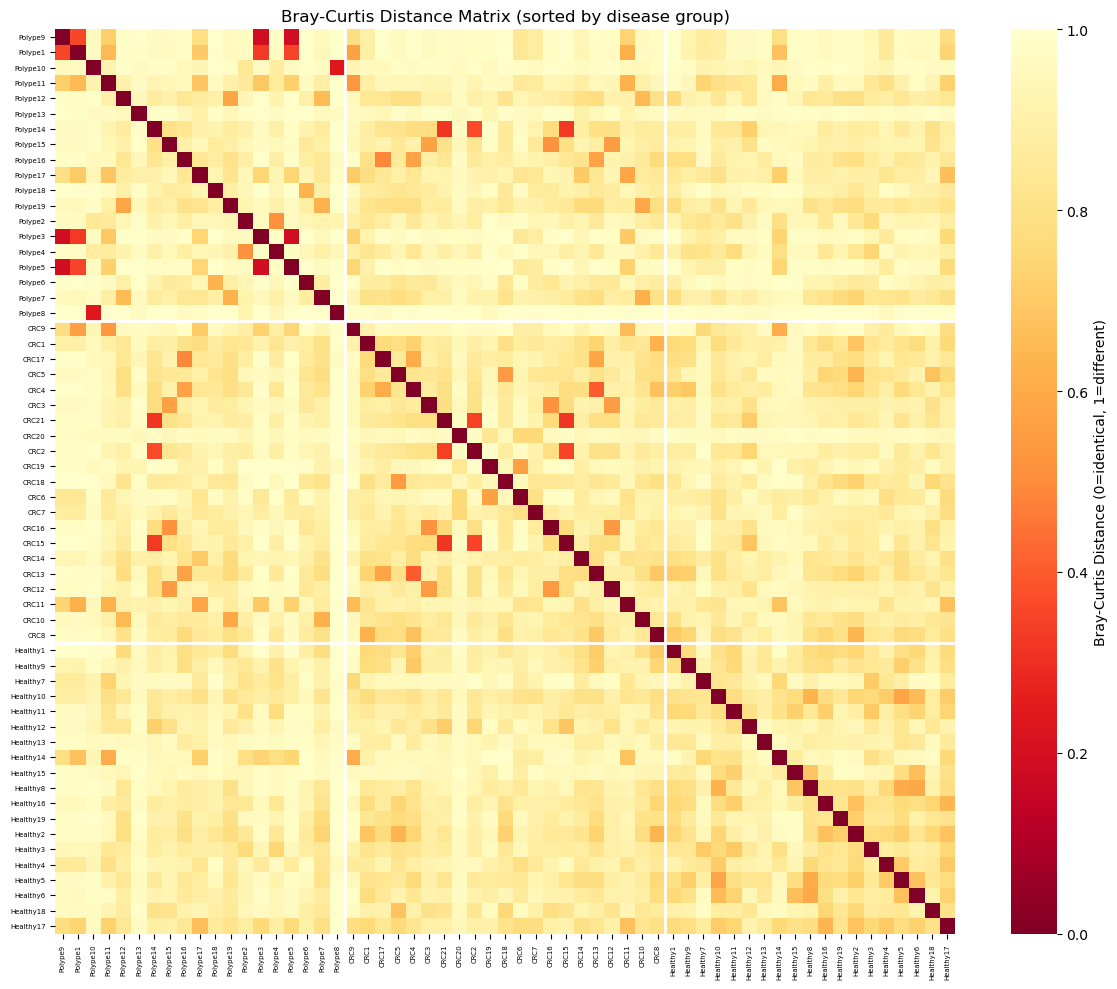

Saved: figures/braycurtis_heatmap.png


In [3]:
# === Cell 3: Heatmap of Bray-Curtis distance matrix ===
# Rationale: Before reducing to 2D with PCoA, we can visualize the full
# distance matrix as a heatmap. Each cell shows how different two samples are.
# We sort samples by disease group so that within-group and between-group
# patterns become visible. If samples within a group are similar to each other,
# you'll see darker blocks along the diagonal.

# Convert distance matrix to DataFrame for easier manipulation
bc_df = bc_dm.to_data_frame()

# Create a mapping from sample ID to disease status
sample_to_group = metadata.set_index('host_disease')['DiseaseStatus']

# Sort samples by disease group
sorted_samples = bc_df.index.to_series().map(sample_to_group).sort_values().index
bc_sorted = bc_df.loc[sorted_samples, sorted_samples]

# Create color labels for the groups
group_colors = {'Healthy': '#2ecc71', 'Adenomatous Polyps': '#f39c12', 'Colorectal cancer': '#e74c3c'}
row_colors = bc_sorted.index.map(sample_to_group).map(group_colors)

# Plot
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(bc_sorted, cmap='YlOrRd_r', ax=ax,
            xticklabels=True, yticklabels=True,
            cbar_kws={'label': 'Bray-Curtis Distance (0=identical, 1=different)'},
            vmin=0, vmax=1)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=5)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=5)
ax.set_title('Bray-Curtis Distance Matrix (sorted by disease group)')

# Add lines to separate groups
group_sizes = bc_sorted.index.map(sample_to_group).value_counts().loc[
    ['Adenomatous Polyps', 'Colorectal cancer', 'Healthy']].values
cumulative = np.cumsum(group_sizes)
for pos in cumulative[:-1]:
    ax.axhline(y=pos, color='white', linewidth=2)
    ax.axvline(x=pos, color='white', linewidth=2)

plt.tight_layout()
fig.savefig('../figures/braycurtis_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/braycurtis_heatmap.png")

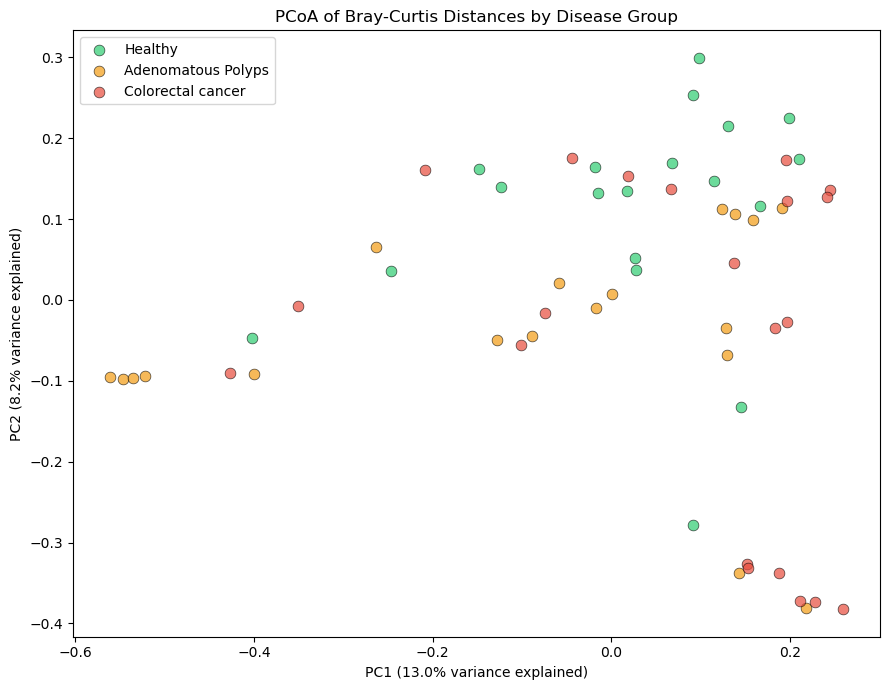

Saved: figures/pcoa_braycurtis.png


In [4]:
# === Cell 4: PCoA visualization colored by disease group ===
# Rationale: PCoA compresses the 59x59 distance matrix into 2 dimensions.
# Each point is a patient. Patients with similar microbiomes appear closer.
# The % on each axis tells how much of the total variation it captures.
# This is the most common figure in microbiome papers.

from skbio.stats.ordination import pcoa

# Run PCoA
pcoa_results = pcoa(bc_dm)

# Extract coordinates and merge with metadata
coords = pcoa_results.samples[['PC1', 'PC2']].copy()
coords['host_disease'] = coords.index
coords = coords.merge(metadata[['host_disease', 'DiseaseStatus']], on='host_disease')

# Variance explained by each axis
var_pc1 = pcoa_results.proportion_explained.iloc[0] * 100
var_pc2 = pcoa_results.proportion_explained.iloc[1] * 100

# Plot
fig, ax = plt.subplots(figsize=(9, 7))
colors = {'Healthy': '#2ecc71', 'Adenomatous Polyps': '#f39c12', 'Colorectal cancer': '#e74c3c'}
group_order = ['Healthy', 'Adenomatous Polyps', 'Colorectal cancer']

for group in group_order:
    subset = coords[coords['DiseaseStatus'] == group]
    ax.scatter(subset['PC1'], subset['PC2'], 
               c=colors[group], label=group, s=60, alpha=0.7, 
               edgecolors='black', linewidth=0.5)

ax.set_xlabel(f'PC1 ({var_pc1:.1f}% variance explained)')
ax.set_ylabel(f'PC2 ({var_pc2:.1f}% variance explained)')
ax.set_title('PCoA of Bray-Curtis Distances by Disease Group')
ax.legend()
plt.tight_layout()
fig.savefig('../figures/pcoa_braycurtis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: figures/pcoa_braycurtis.png")

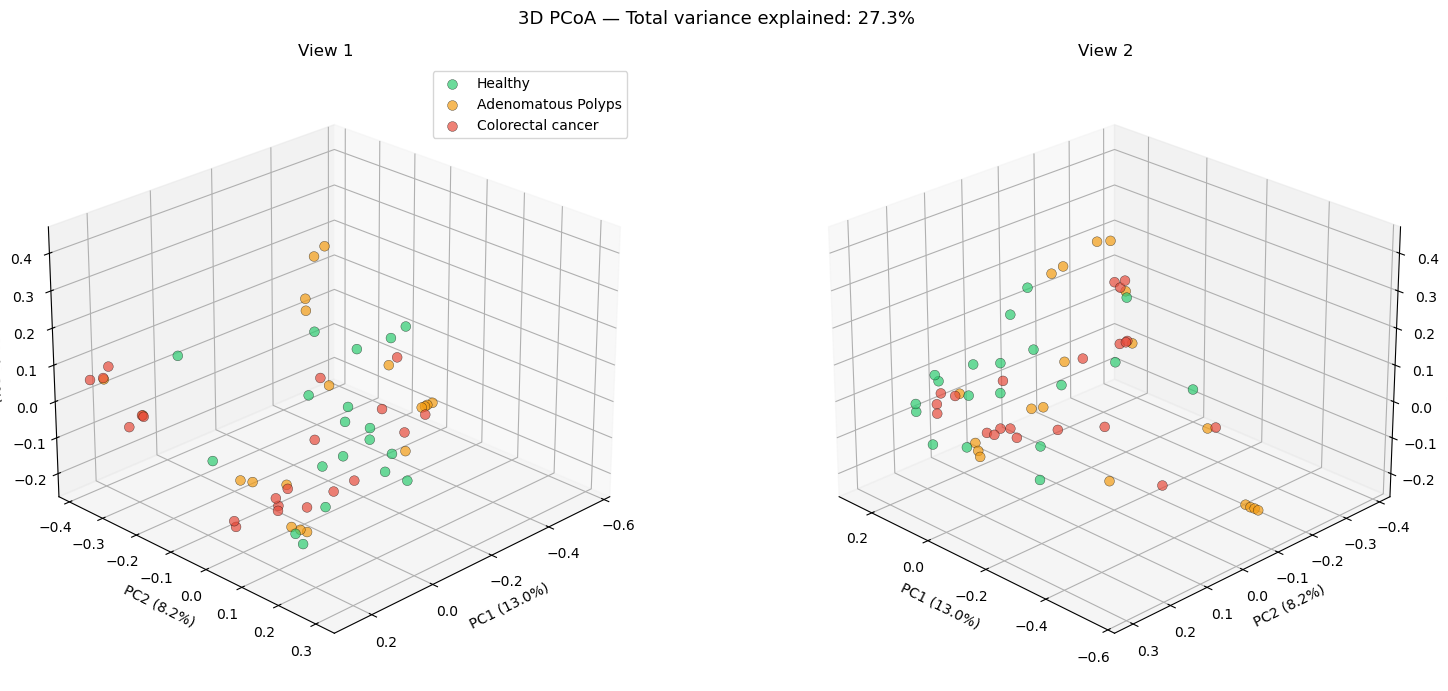


Variance explained: PC1=13.0% + PC2=8.2% + PC3=6.1% = 27.3%


In [5]:
# === Cell 5: 3D PCoA visualization ===
# Rationale: PC1 and PC2 only capture ~21% of variation. Adding PC3 might
# reveal separation between groups hidden in the 2D projection.
# We use matplotlib's 3D projection for an interactive-style view.

from mpl_toolkits.mplot3d import Axes3D

# Extract 3 axes
coords_3d = pcoa_results.samples[['PC1', 'PC2', 'PC3']].copy()
coords_3d['host_disease'] = coords_3d.index
coords_3d = coords_3d.merge(metadata[['host_disease', 'DiseaseStatus']], on='host_disease')

var_pc3 = pcoa_results.proportion_explained.iloc[2] * 100
total_var = var_pc1 + var_pc2 + var_pc3

# Plot from two different angles to see more structure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7),
                                subplot_kw={'projection': '3d'})

for ax, elev, azim, title in [(ax1, 25, 45, 'View 1'), (ax2, 25, 135, 'View 2')]:
    for group in group_order:
        subset = coords_3d[coords_3d['DiseaseStatus'] == group]
        ax.scatter(subset['PC1'], subset['PC2'], subset['PC3'],
                   c=colors[group], label=group, s=50, alpha=0.7,
                   edgecolors='black', linewidth=0.3)
    ax.set_xlabel(f'PC1 ({var_pc1:.1f}%)')
    ax.set_ylabel(f'PC2 ({var_pc2:.1f}%)')
    ax.set_zlabel(f'PC3 ({var_pc3:.1f}%)')
    ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)

ax1.legend()
fig.suptitle(f'3D PCoA — Total variance explained: {total_var:.1f}%', fontsize=13)
plt.tight_layout()
fig.savefig('../figures/pcoa_3d.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nVariance explained: PC1={var_pc1:.1f}% + PC2={var_pc2:.1f}% + PC3={var_pc3:.1f}% = {total_var:.1f}%")

In [7]:
# === Cell 6: Interactive 3D PCoA with Plotly ===
# Rationale: Static 3D plots are hard to interpret because you can't rotate them.
# Plotly generates an interactive HTML widget where you can click and drag
# to rotate, zoom, and hover over points to see which sample they are.

import plotly.express as px

# Prepare data
plot_3d = coords_3d.copy()

fig = px.scatter_3d(
    plot_3d, x='PC1', y='PC2', z='PC3',
    color='DiseaseStatus',
    color_discrete_map=colors,
    hover_name='host_disease',
    category_orders={'DiseaseStatus': group_order},
    labels={
        'PC1': f'PC1 ({var_pc1:.1f}%)',
        'PC2': f'PC2 ({var_pc2:.1f}%)',
        'PC3': f'PC3 ({var_pc3:.1f}%)'
    },
    title=f'Interactive 3D PCoA — Total variance: {total_var:.1f}%'
)

fig.update_traces(marker=dict(size=5, line=dict(width=0.5, color='black')))
fig.update_layout(width=800, height=600)
fig.show()

In [10]:
# === Cell 7: PERMANOVA test ===
# Rationale: PERMANOVA tests if microbiome composition differs between groups
# using the full distance matrix — not just the 2D/3D projection from PCoA.
# It shuffles group labels 999 times and compares real vs random distances.

from skbio.stats.distance import permanova

# Create a named grouping Series matching the distance matrix sample order
grouping = bc_dm.ids
group_map = metadata.set_index('host_disease')['DiseaseStatus']
groups_series = pd.Series([group_map[s] for s in grouping], index=grouping, name='DiseaseStatus')

# Run PERMANOVA with 999 permutations
result = permanova(bc_dm, groups_series, permutations=999)

print("=== PERMANOVA RESULTS ===\n")
print(f"Test statistic (F): {result['test statistic']:.3f}")
print(f"p-value:            {result['p-value']:.4f}")
print(f"Permutations:       {result['number of permutations']}")

if result['p-value'] < 0.05:
    print("\nResult: SIGNIFICANT — microbiome composition differs between groups")
else:
    print("\nResult: NOT significant — no evidence of compositional differences")

=== PERMANOVA RESULTS ===

Test statistic (F): 2.283
p-value:            0.0010
Permutations:       999

Result: SIGNIFICANT — microbiome composition differs between groups
